# IND320 - Part 1: Reservoirs

This notebook explores reservoir data and documents the analysis used in the Streamlit app.

## 1. Data and source

The dataset comes from the [IND320 course material](https://github.com/khliland/IND320/blob/main/D2Dbook/data/reservoirs.csv). A local copy is stored in `data/reservoirs.csv`. The file was downloaded on 16 September 2026.

The data contains several area types. These need to be kept separate when plotting time series.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Read the local CSV file and convert the date column to datetime.
data = pd.read_csv(Path("data/reservoirs.csv"), parse_dates=["dato_Id"])
data.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 2. English column names

In [2]:
# Use clear names and keep TWh in the names of the energy columns.
data = data.rename(columns={
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "filling_ratio",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_filling_ratio",
    "endring_fyllingsgrad": "weekly_filling_ratio_change",
})
data.head()

,date,area_type,area_number,iso_year,iso_week,filling_ratio,capacity_twh,stored_energy_twh,next_publication_date,previous_week_filling_ratio,weekly_filling_ratio_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 3. Checking the data

In [3]:
# Check the number of rows, date range and areas in the file.
print(f"Number of rows: {len(data):,}")
print(f"Date range: {data["date"].min():%d.%m.%Y}-{data["date"].max():%d.%m.%Y}")
print("\nRows per area:")
print(data.groupby(["area_type", "area_number"]).size())
print("\nMissing values per column:")
print(data.isna().sum())

Number of rows: 14,877
Date range: 08.01.1995-06.09.2026

Rows per area:
area_type  area_number
EL         1              1653
           2              1653
           3              1653
           4              1653
           5              1653
NO         0              1653
VASS       1              1653
           2              1653
           3              1653
dtype: int64

Missing values per column:
date                           0
area_type                      0
area_number                    0
iso_year                       0
iso_week                       0
filling_ratio                  0
capacity_twh                   0
stored_energy_twh              0
next_publication_date          0
previous_week_filling_ratio    0
weekly_filling_ratio_change    0
dtype: int64


In [4]:
# Check the data types before choosing columns to plot.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         14877 non-null  datetime64[us]
 1   area_type                    14877 non-null  str           
 2   area_number                  14877 non-null  int64         
 3   iso_year                     14877 non-null  int64         
 4   iso_week                     14877 non-null  int64         
 5   filling_ratio                14877 non-null  float64       
 6   capacity_twh                 14877 non-null  float64       
 7   stored_energy_twh            14877 non-null  float64       
 8   next_publication_date        14877 non-null  str           
 9   previous_week_filling_ratio  14877 non-null  float64       
 10  weekly_filling_ratio_change  14877 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(3), str(2)
m

### First observations

The file contains several areas for each date, and the rows are not in date order. To get a continuous series, I select one area and sort the rows by date.

`next_publication_date` also contains the placeholder `0001-01-01T00:00:00`. This column describes publication dates, not measurement dates. Filling level is stored as a fraction and shown as a percentage in the first plot.

## 4. First plot: filling level for NO, 0

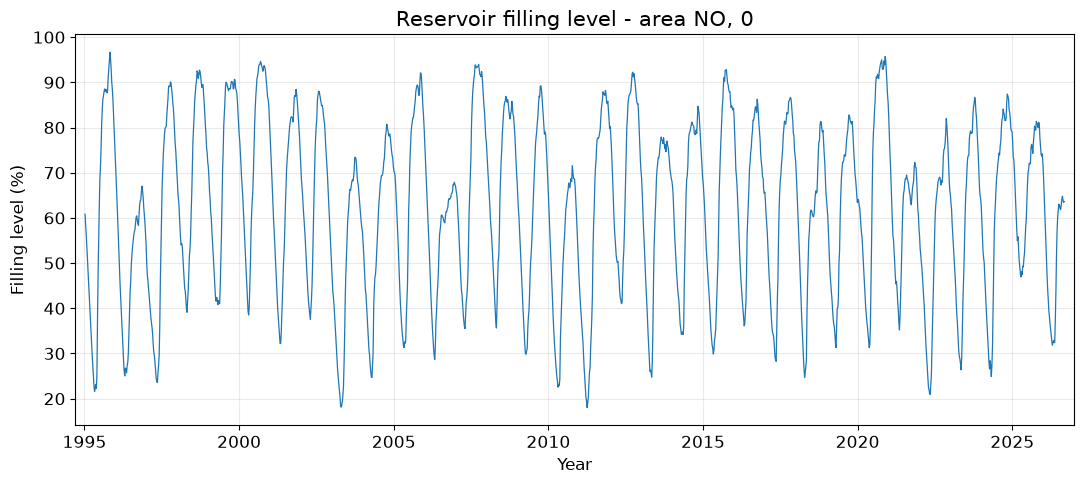

In [5]:
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# Use larger text and a few date labels for readable notebook figures.
plt.rcParams.update({"font.size": 12, "axes.titlesize": 15, "axes.labelsize": 12})

def format_dates(ax):
    locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.margins(x=0.01)

# Select area NO, 0 and sort the measurements from oldest to newest.
national = data.loc[
    (data["area_type"] == "NO") & (data["area_number"] == 0)
].sort_values("date")

# Multiply by 100 to show filling level as a percentage.
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national["date"], national["filling_ratio"] * 100, linewidth=0.9)
ax.set_title("Reservoir filling level - area NO, 0")
ax.set_xlabel("Year")
ax.set_ylabel("Filling level (%)")
ax.grid(alpha=0.25)
format_dates(ax)
fig.tight_layout()
plt.show()

## 5. Plotting each measurement column

I continue with area `NO, 0`, so all points in each line belong to the same area. In these plots, filling level and weekly change are shown in their original units as fractions.

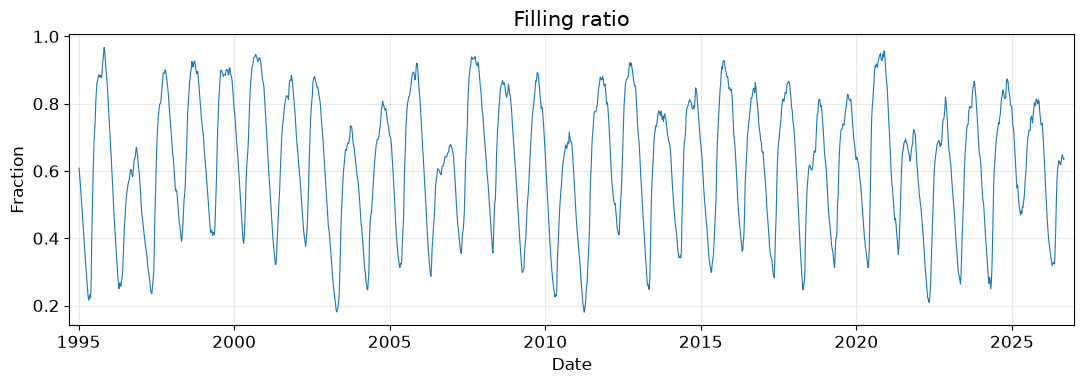

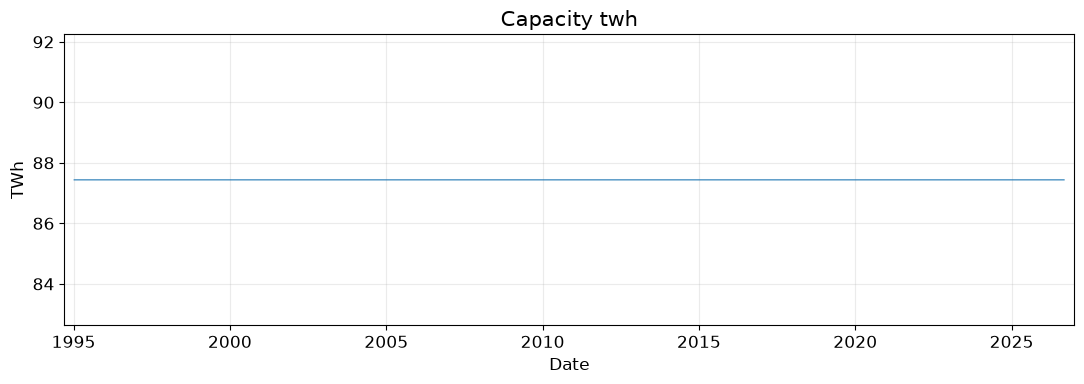

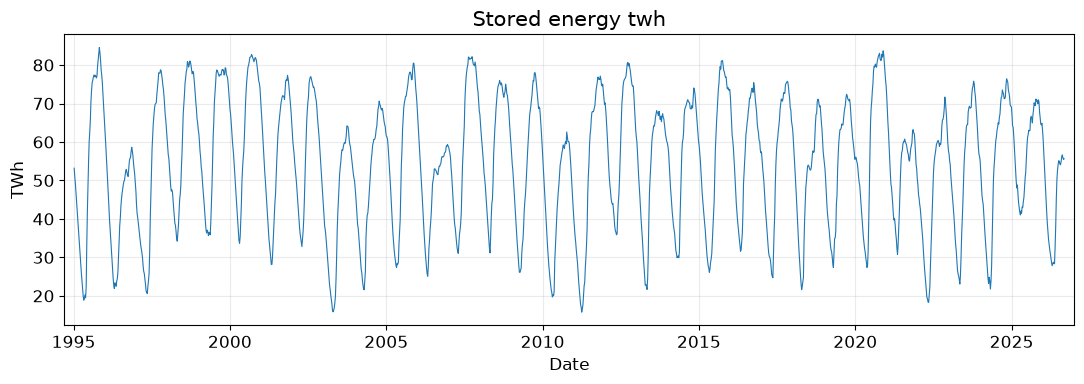

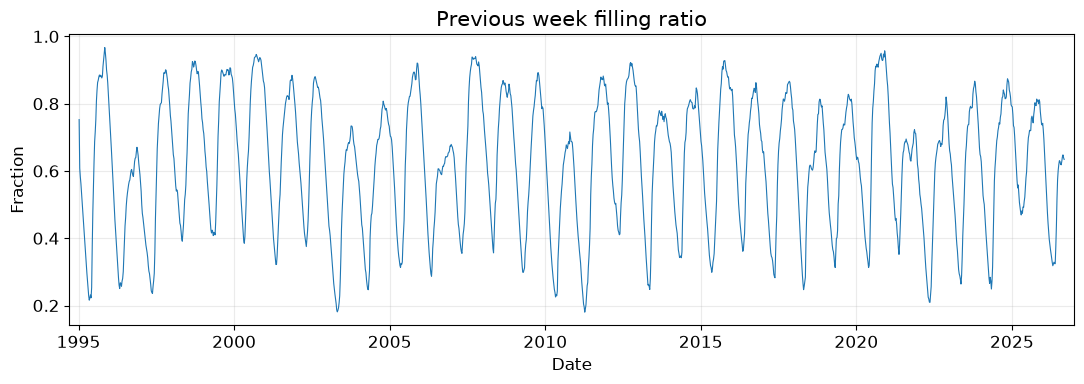

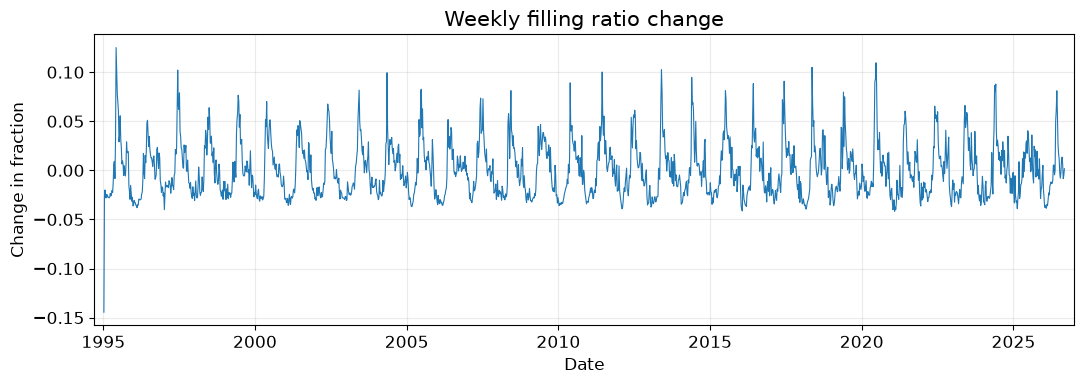

In [6]:
# These five columns contain measurements rather than dates or area codes.
measurements = ["filling_ratio", "capacity_twh", "stored_energy_twh",
                "previous_week_filling_ratio", "weekly_filling_ratio_change"]
units = ["Fraction", "TWh", "TWh", "Fraction", "Change in fraction"]
for column, unit in zip(measurements, units):
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(national["date"], national[column], linewidth=0.8)
    ax.set(title=column.replace("_", " ").capitalize(), xlabel="Date", ylabel=unit)
    ax.grid(alpha=0.25)
    format_dates(ax)
    fig.tight_layout()
    plt.show()

### Dates and area codes

The assignment asks for a plot of each column. The remaining columns describe the data: area codes, calendar values and publication dates. They are plotted separately below. The placeholder publication date is treated as missing in the plot. The original data is kept unchanged.

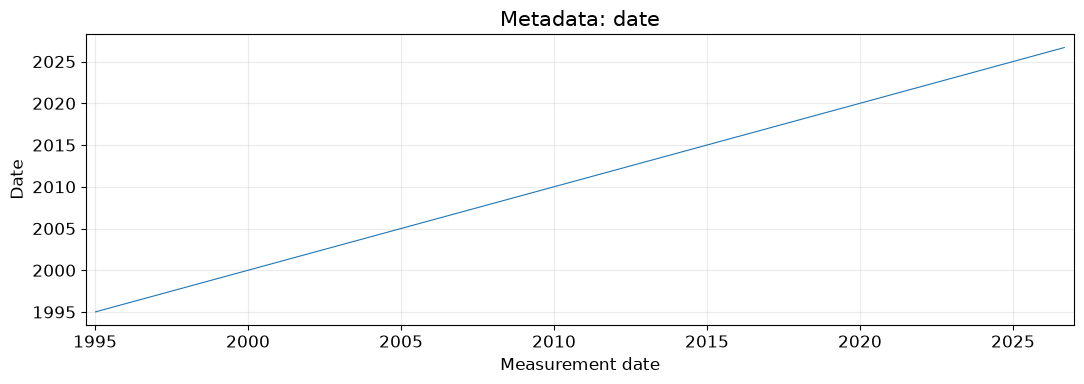

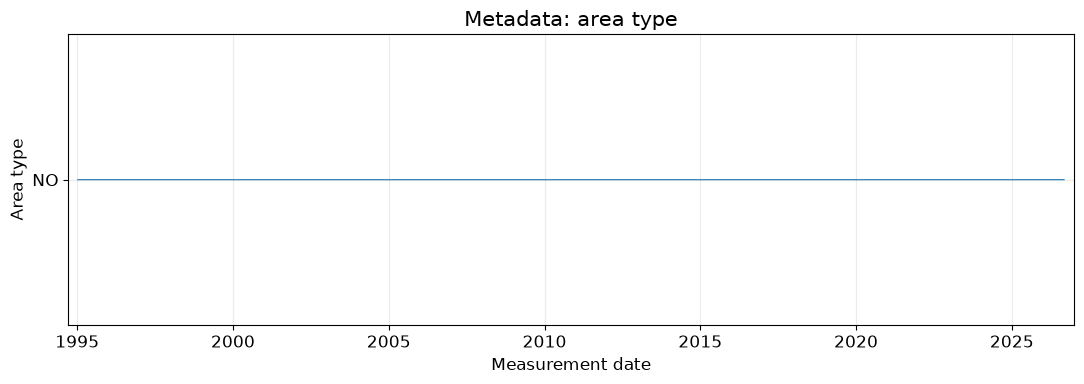

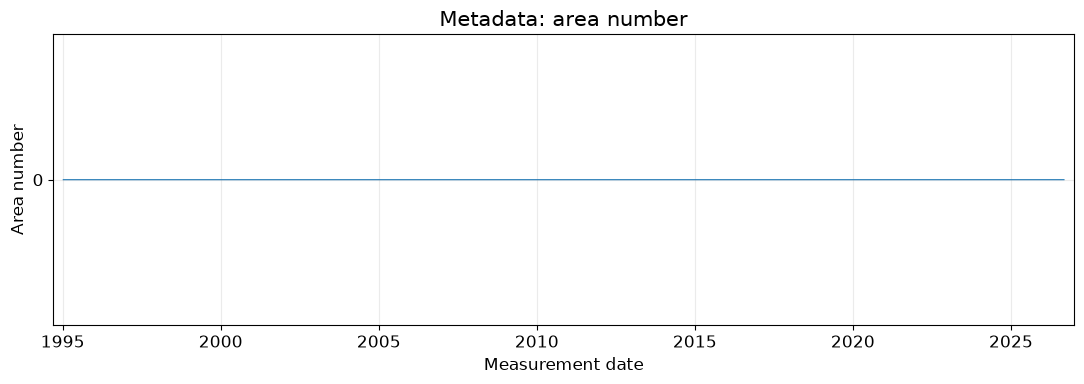

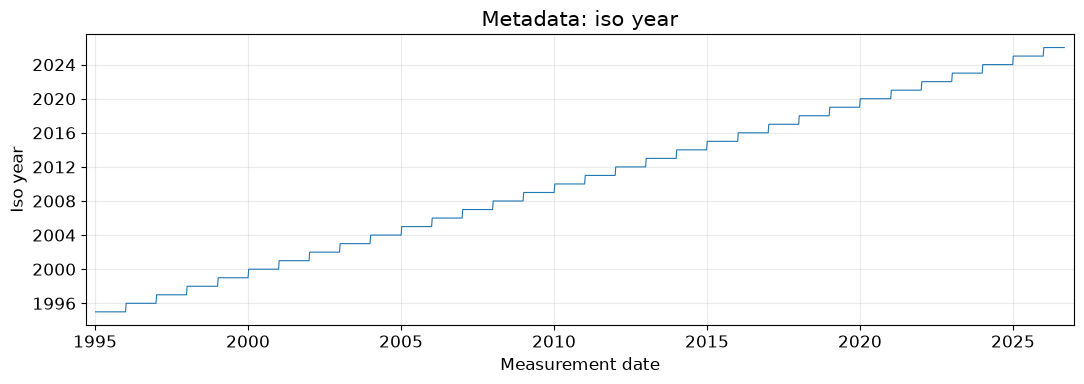

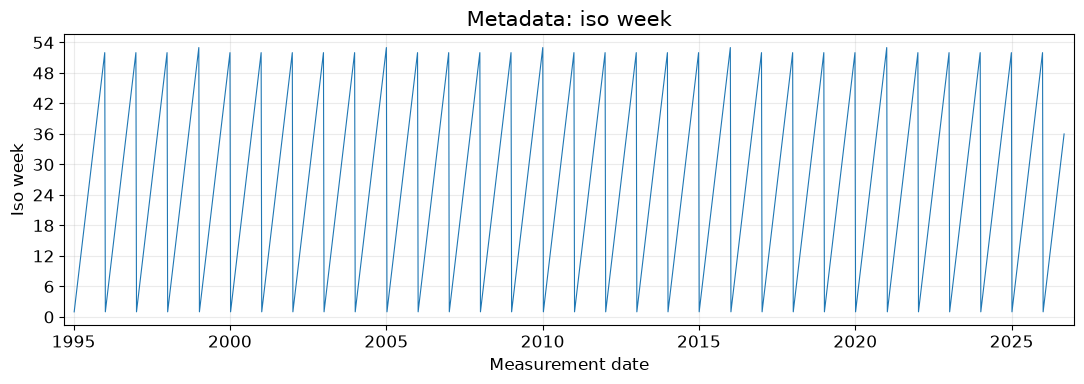

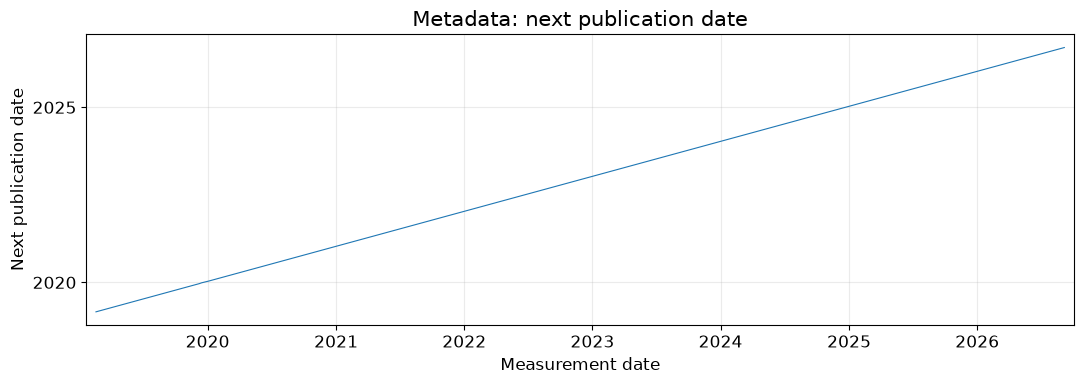

In [7]:
# Plot metadata separately from the measurement comparison.
metadata_columns = [column for column in national.columns if column not in measurements]
for column in metadata_columns:
    values = national[column]
    if column == "next_publication_date":
        values = pd.to_datetime(values.mask(values.str.startswith("0001")), errors="coerce")
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(national["date"], values, linewidth=0.8)
    ax.set(title=f"Metadata: {column.replace('_', ' ')}", xlabel="Measurement date", ylabel=column.replace("_", " ").capitalize())
    if column in ["area_number", "iso_year", "iso_week"]:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        if values.nunique() == 1:
            value = values.iloc[0]
            ax.set_yticks([value])
            ax.set_ylim(value - 0.5, value + 0.5)
    if column in ["date", "next_publication_date"]:
        ax.yaxis.set_major_locator(mdates.YearLocator(5))
        ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(alpha=0.25)
    format_dates(ax)
    fig.tight_layout()
    plt.show()

## 6. Plotting the measurements together

TWh and filling level have different scales. I therefore use min-max scaling: `(value - minimum) / (maximum - minimum)`. Each series gets values between 0 and 1. This makes changes easier to compare, but hides differences in absolute values.

A constant series has no variation and is shown as 0. The full time period for the area is used as the reference, including when a shorter period is selected in Streamlit.

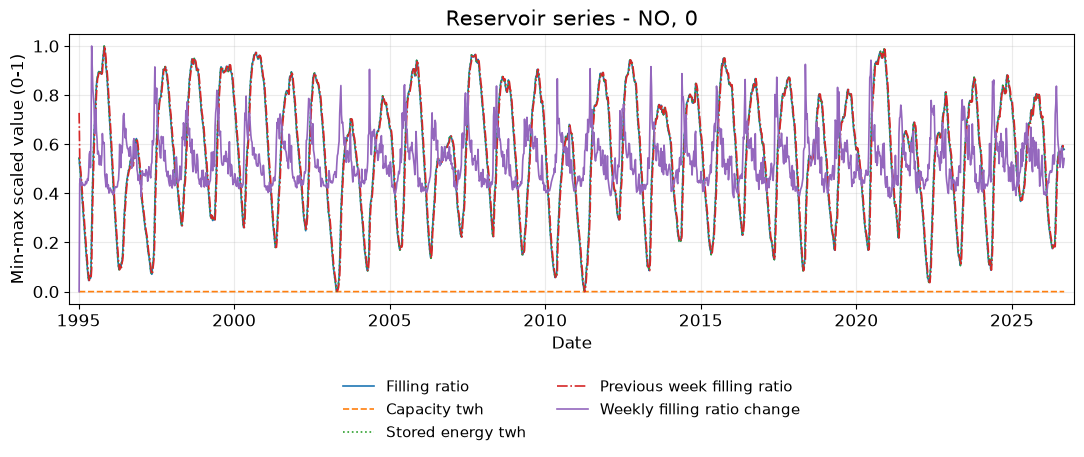

In [8]:
# Replace a zero denominator with 1 to handle constant columns.
minimum = national[measurements].min()
span = national[measurements].max() - minimum
scaled = (national[measurements] - minimum) / span.replace(0, 1)
fig, ax = plt.subplots(figsize=(11, 5))
for column, style in zip(measurements, ["-", "--", ":", "-.", "-"]):
    ax.plot(national["date"], scaled[column], label=column.replace("_", " ").capitalize(), linestyle=style, linewidth=1.2)
ax.set(title="Reservoir series - NO, 0", xlabel="Date", ylabel="Min-max scaled value (0-1)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.23), ncol=2, fontsize=11, frameon=False)
ax.grid(alpha=0.25)
format_dates(ax)
fig.tight_layout()
plt.show()

### Interpretation and limitations

Filling level rises and falls repeatedly over the period. The lines for filling level and the previous week's filling level are close because one is shifted by a week. Stored energy also follows filling level, while capacity is constant for this area in the supplied file. Constant capacity in this dataset does not show that the actual capacity has never changed.


## 7. Streamlit

The app has four separate page files. `app.py` is the home page, and the files in `pages/` appear in the sidebar menu. `data_utils.py` reads the CSV file with `st.cache_data` and uses the same column names as the notebook.

The table has one row per CSV column and a `LineChartColumn` for numeric values in the first calendar month. Text and dates are shown without a small chart. On the plots page, the user selects an area, a column and a range of months. Both slider handles start at the first month. The fourth page has test content for later work.

Documentation: [LineChartColumn](https://docs.streamlit.io/develop/api-reference/data/st.column_config/st.column_config.linechartcolumn), [select_slider](https://docs.streamlit.io/develop/api-reference/widgets/st.select_slider).

## 8. GitHub and Streamlit

GitHub: [Sipan2/IND320-Sipan2](https://github.com/Sipan2/IND320-Sipan2)

Streamlit app: [ind320-sipan2.streamlit.app](https://ind320-sipan2.streamlit.app/)

The screencast is available on GitHub: [Watch the video](https://github.com/Sipan2/IND320-Sipan2/blob/main/IND320-Part-1-screencast.mp4).


## 9. Use of AI

I have used Codex for support with programming in Python, Jupyter Notebook and Streamlit. The project includes both code I have written myself and code created with help from AI. Codex has contributed code suggestions, debugging and technical testing. The reflections are my own, but I used AI to help with wording and translation into English.

## 10. Work log

I started by creating the project folders and setting up the work in VS Code. From there, I worked on the notebook and the CSV file. The first aim was to get an overview of the data before using it in Streamlit. I wrote some of the code myself and used Codex for support with other parts of the programming.

In the notebook, the CSV file is read with Pandas. The columns were given English names, and the first rows, data types and missing values were checked. This provided a starting point for the plots.

One technical challenge was the structure of the dataset. It contains measurements from several areas, and the rows are not in date order. Plotting everything directly would connect points from different areas. The solution was to select one area at a time and sort its measurements by date. This step matters even when the plotting code runs without an error, because a working plot can still give a misleading picture.

The columns were then plotted separately and together. The separate plots keep their original units. Combining them needed another approach: filling level is a fraction, while stored energy is measured in TWh. The comparison plot therefore uses min-max scaling between 0 and 1. It shows relative changes, while the separate plots show the actual values. Constant columns are handled separately in the calculation to avoid division by zero.

The Streamlit app makes the same data available through four pages. The data table shows small line charts for the first month. On the plots page, the user can change the area, column and month range. Both slider handles start at the first month. Caching is used so that changing a selection does not require reading the CSV file again.

I wanted the project to stay simple and the explanations to use plain language. I gave feedback on the wording and structure during the work. My own coding and the AI assistance are described separately in the AI statement.

The notebook and app serve different purposes. The notebook records the analysis step by step, while Streamlit lets the user explore the results. All notebook cells were run, and the four app pages were tested locally, including the column choices and month slider. The figures were also checked for readable dates, labels and legends.
